In [2]:
import sys

print(sys.executable)

c:\Users\anupg\OneDrive\Desktop\ecommerce-sales-analysis\venv\Scripts\python.exe


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("E-commerce Sales Analysis Project")
print("Environment is working!")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

E-commerce Sales Analysis Project
Environment is working!
Pandas version: 3.0.5
NumPy version: 2.5.2


In [3]:
from pathlib import Path
import pandas as pd

# Path to raw data
data_path = Path("../data/raw/Ecommerce_Sales_Data_2024_2025.csv")

# Load dataset
df = pd.read_csv(data_path)

# Display first 5 rows
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


In [4]:
# Check dataset size
print("Rows and Columns:", df.shape)

# Check column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check data types
print("\nData Types:")
print(df.dtypes)

Rows and Columns: (5000, 14)

Column Names:
['Order ID', 'Order Date', 'Customer Name', 'Region', 'City', 'Category', 'Sub-Category', 'Product Name', 'Quantity', 'Unit Price', 'Discount', 'Sales', 'Profit', 'Payment Mode']

Data Types:
Order ID           int64
Order Date           str
Customer Name        str
Region               str
City                 str
Category             str
Sub-Category         str
Product Name         str
Quantity           int64
Unit Price         int64
Discount           int64
Sales            float64
Profit           float64
Payment Mode         str
dtype: object


In [5]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values in each column:
Order ID         0
Order Date       0
Customer Name    0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
dtype: int64

Number of duplicate rows:
0


In [6]:
# Check the date range
print("Minimum Order Date:", df["Order Date"].min())
print("Maximum Order Date:", df["Order Date"].max())

# Show the unique years present
print("\nYears present in the dataset:")
print(pd.to_datetime(df["Order Date"]).dt.year.value_counts().sort_index())

Minimum Order Date: 2023-10-04
Maximum Order Date: 2025-10-03

Years present in the dataset:
Order Date
2023     601
2024    2532
2025    1867
Name: count, dtype: int64


In [7]:
# Check numerical columns
print("Quantity:")
print(df["Quantity"].describe())

print("\nUnit Price:")
print(df["Unit Price"].describe())

print("\nDiscount:")
print(df["Discount"].describe())

print("\nSales:")
print(df["Sales"].describe())

print("\nProfit:")
print(df["Profit"].describe())

Quantity:
count    5000.000000
mean        2.992600
std         1.413133
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Quantity, dtype: float64

Unit Price:
count     5000.000000
mean     39760.904600
std      22831.783946
min        222.000000
25%      20312.250000
50%      39459.500000
75%      59721.750000
max      79998.000000
Name: Unit Price, dtype: float64

Discount:
count    5000.000000
mean       10.051000
std         7.084662
min         0.000000
25%         5.000000
50%        10.000000
75%        15.000000
max        20.000000
Name: Discount, dtype: float64

Sales:
count      5000.000000
mean     106733.204870
std       85108.208202
min         264.100000
25%       39766.537500
50%       83080.325000
75%      156968.587500
max      398485.000000
Name: Sales, dtype: float64

Profit:
count     5000.000000
mean     15941.746982
std      14897.684916
min         19.120000
25%       4892.295000
50%      11108.52500

In [8]:
# Check for invalid numerical values

print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("Unit Price <= 0:", (df["Unit Price"] <= 0).sum())
print("Discount < 0:", (df["Discount"] < 0).sum())
print("Discount > 100:", (df["Discount"] > 100).sum())
print("Sales < 0:", (df["Sales"] < 0).sum())
print("Profit < 0:", (df["Profit"] < 0).sum())

Quantity <= 0: 0
Unit Price <= 0: 0
Discount < 0: 0
Discount > 100: 0
Sales < 0: 0
Profit < 0: 0


In [9]:
# Convert Order Date from text to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Check the new data type
print(df["Order Date"].dtype)

# Display a few dates
print("\nSample dates:")
print(df["Order Date"].head())

datetime64[us]

Sample dates:
0   2024-10-19
1   2025-08-30
2   2023-11-04
3   2025-05-23
4   2025-01-19
Name: Order Date, dtype: datetime64[us]


In [10]:
# Check unique values in categorical columns

print("Regions:")
print(df["Region"].unique())

print("\nCategories:")
print(df["Category"].unique())

print("\nSub-Categories:")
print(df["Sub-Category"].unique())

print("\nPayment Modes:")
print(df["Payment Mode"].unique())

Regions:
<StringArray>
['South', 'North', 'East', 'West']
Length: 4, dtype: str

Categories:
<StringArray>
[      'Books',   'Groceries',     'Kitchen',    'Clothing',   'Furniture',
      'Beauty',  'Home Decor', 'Electronics',      'Sports',        'Toys']
Length: 10, dtype: str

Sub-Categories:
<StringArray>
[  'Non-Fiction',          'Rice',        'Juicer',           'Oil',
     'Kids Wear',         'Chair',   'Accessories',     'Biography',
        'Spices',  'Cookware Set',       'Perfume',          'Vase',
  'Women's Wear',        'Laptop',    'Smartwatch',     'Dumbbells',
      'Textbook',  'Refrigerator',         'Wheat',        'Comics',
    'Face Cream',    'Headphones',    'Foundation',         'Table',
        'RC Car',         'Sugar',   'Cricket Bat',          'Sofa',
 'Action Figure',      'Lipstick',      'Yoga Mat',        'Puzzle',
    'Board Game',          'Doll',        'Camera', 'Tennis Racket',
         'Shoes',           'Bed',      'Wall Art',       'Cabinet

In [11]:
# Check for leading/trailing spaces in text columns

text_columns = df.select_dtypes(include="str").columns

for col in text_columns:
    spaces = (df[col] != df[col].str.strip()).sum()
    print(f"{col}: {spaces} values with extra spaces")

Customer Name: 0 values with extra spaces
Region: 0 values with extra spaces
City: 0 values with extra spaces
Category: 0 values with extra spaces
Sub-Category: 0 values with extra spaces
Product Name: 0 values with extra spaces
Payment Mode: 0 values with extra spaces


In [12]:
from pathlib import Path

# Create processed-data folder if it doesn't exist
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# Save cleaned dataset
processed_path = processed_dir / "ecommerce_sales_cleaned.csv"
df.to_csv(processed_path, index=False)

print("Cleaned dataset saved successfully!")
print("Location:", processed_path)
print("Rows:", len(df))
print("Columns:", len(df.columns))

Cleaned dataset saved successfully!
Location: ..\data\processed\ecommerce_sales_cleaned.csv
Rows: 5000
Columns: 14


In [13]:
# Overall business performance

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity Sold:", total_quantity)

Total Sales: 533666024.35
Total Profit: 79708734.91
Total Quantity Sold: 14963


In [14]:
# Create Year-Month column
df["Year-Month"] = df["Order Date"].dt.to_period("M")

# Monthly sales and profit
monthly_performance = df.groupby("Year-Month")[["Sales", "Profit"]].sum()

print(monthly_performance)

                  Sales      Profit
Year-Month                         
2023-10     21307522.20  3106231.10
2023-11     22040269.20  3387740.08
2023-12     20624240.25  2989330.92
2024-01     21477241.40  3104253.86
2024-02     19853396.50  2941448.82
2024-03     21571015.35  3235674.53
2024-04     22214781.10  3241579.85
2024-05     24744786.55  3692958.55
2024-06     21368962.50  3261199.09
2024-07     24019283.90  3486946.19
2024-08     23299894.50  3404785.08
2024-09     22480182.05  3292917.74
2024-10     23607626.65  3601281.93
2024-11     22036247.55  3286992.25
2024-12     24806786.40  3855729.92
2025-01     21520801.80  3255994.46
2025-02     19902446.10  2970431.02
2025-03     22602988.75  3533884.47
2025-04     21653817.90  3150564.23
2025-05     26010928.65  3979356.67
2025-06     21155496.20  3184539.18
2025-07     22526567.55  3439384.07
2025-08     23317916.20  3456953.24
2025-09     18131496.70  2677363.66
2025-10      1391328.40   171194.00


In [15]:
# Find highest and lowest complete months

# Exclude the partial October 2025
complete_months = monthly_performance[
    monthly_performance.index != "2025-10"
]

# Highest sales month
highest_sales_month = complete_months["Sales"].idxmax()
highest_sales_value = complete_months["Sales"].max()

# Lowest sales month
lowest_sales_month = complete_months["Sales"].idxmin()
lowest_sales_value = complete_months["Sales"].min()

print("Highest Sales Month:", highest_sales_month)
print("Highest Sales:", highest_sales_value)

print("\nLowest Complete Month:", lowest_sales_month)
print("Lowest Complete Month Sales:", lowest_sales_value)

Highest Sales Month: 2025-05
Highest Sales: 26010928.65

Lowest Complete Month: 2025-09
Lowest Complete Month Sales: 18131496.7


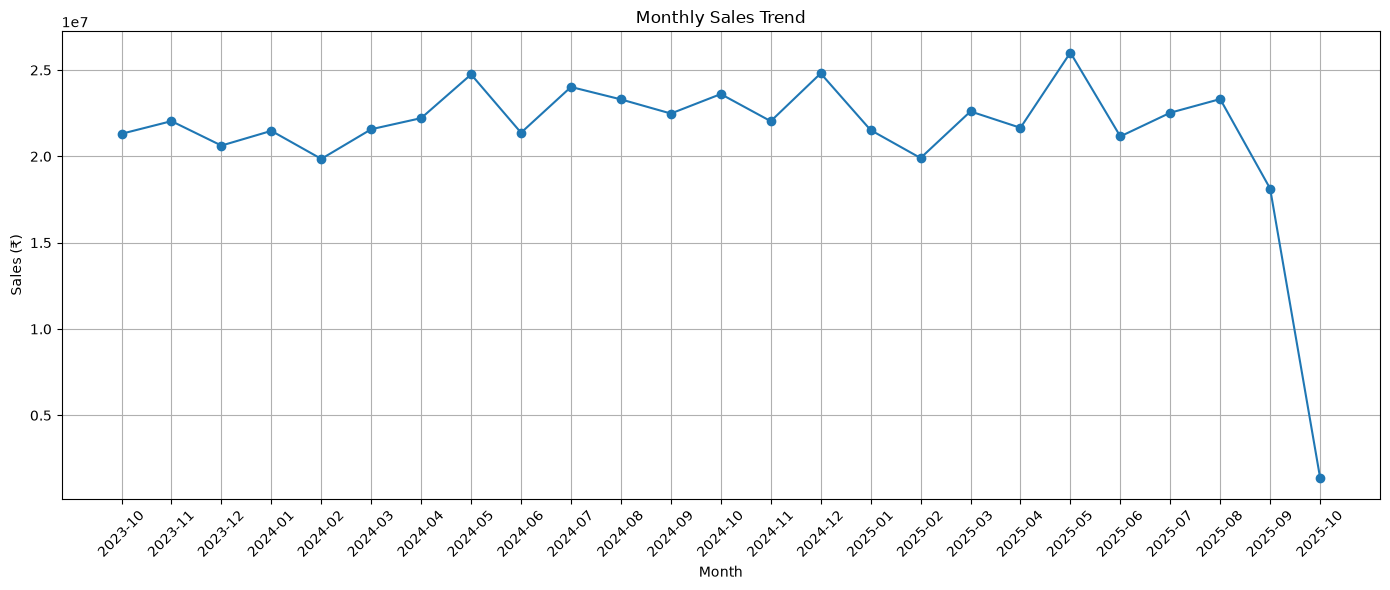

In [16]:
# Monthly Sales Trend

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_performance.index.astype(str),
    monthly_performance["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

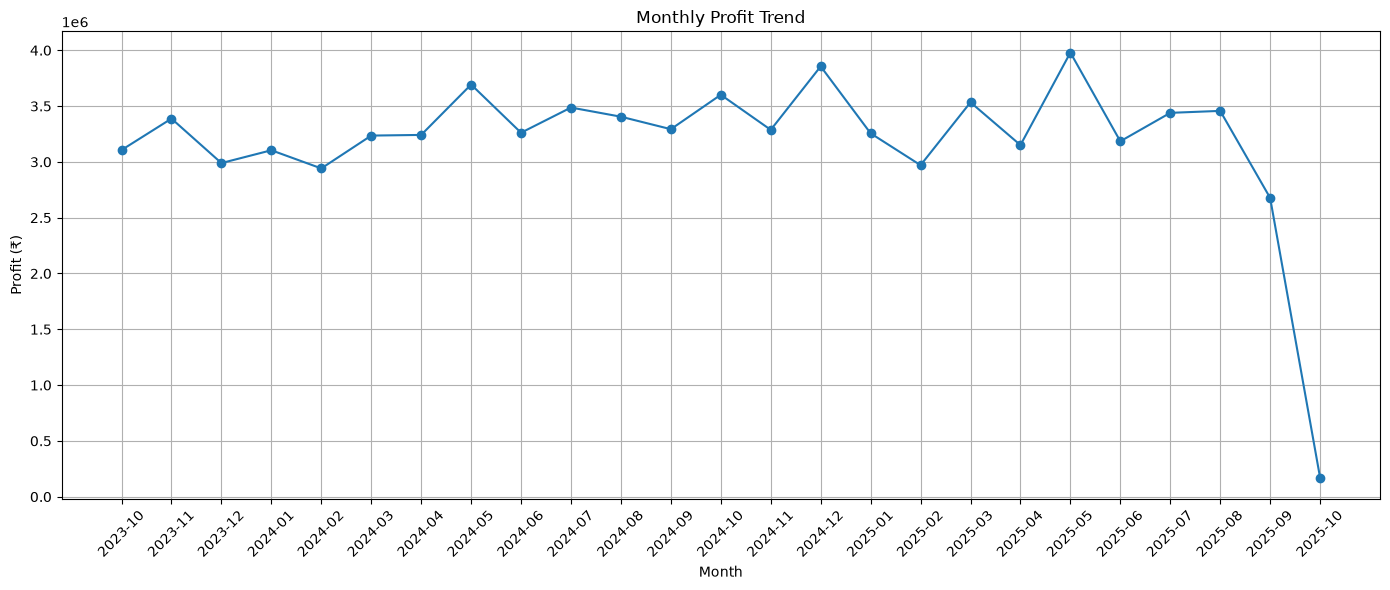

In [17]:
# Monthly Profit Trend

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_performance.index.astype(str),
    monthly_performance["Profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit (₹)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [18]:
# Category-wise Sales and Profit

category_performance = (
    df.groupby("Category")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

print(category_performance)

                   Sales      Profit
Category                            
Home Decor   57233222.35  8556846.94
Furniture    56647187.90  8693087.03
Clothing     55053908.30  8445750.29
Books        54932643.00  8076273.29
Kitchen      54227902.30  7879573.29
Electronics  52587883.95  8042133.88
Toys         52227366.45  7986871.44
Sports       52069397.25  7739430.04
Beauty       50803409.70  7213436.07
Groceries    47883103.15  7075332.64


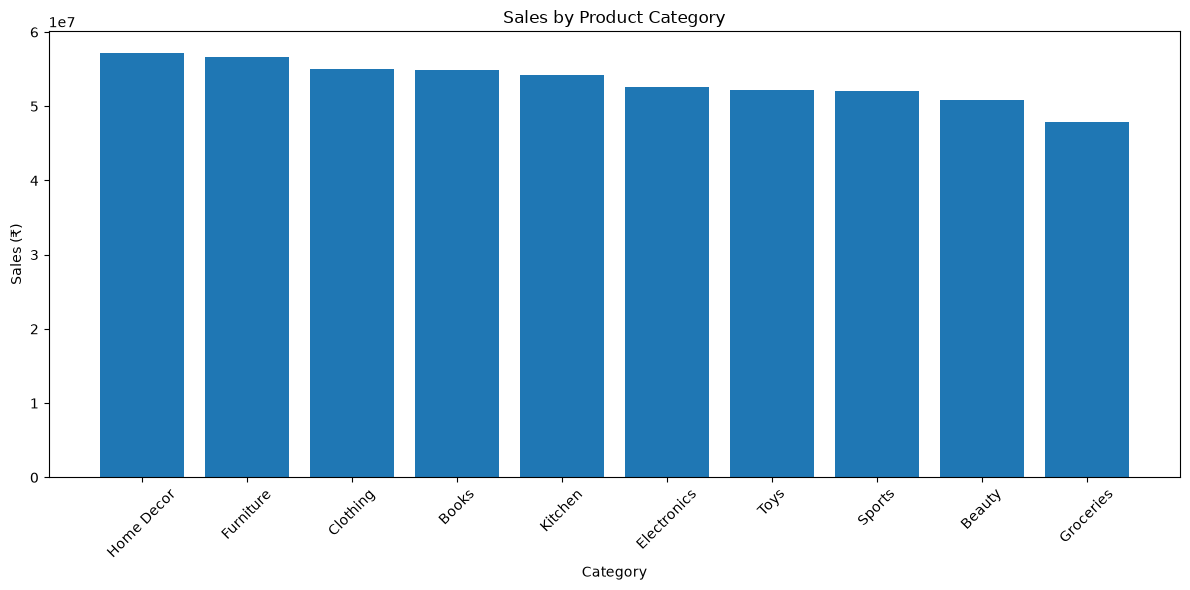

In [19]:
# Sales by Category

plt.figure(figsize=(12, 6))

plt.bar(
    category_performance.index,
    category_performance["Sales"]
)

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

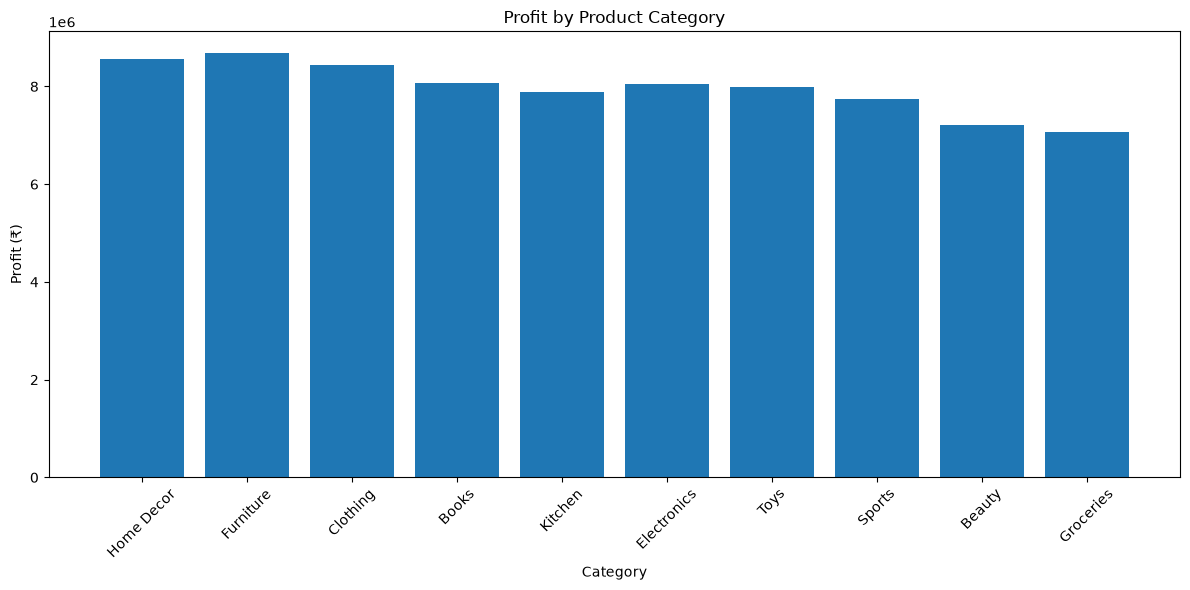

In [20]:
# Profit by Category

plt.figure(figsize=(12, 6))

plt.bar(
    category_performance.index,
    category_performance["Profit"]
)

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit (₹)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [21]:
# Top 10 Products by Sales

top_products_sales = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_sales)

Product Name
Headphones Accusantium     857184.20
Spices Quibusdam           687651.25
Accessories Repellendus    687083.30
Bed Tenetur                670994.80
Laptop Similique           666640.60
Lamp Enim                  665920.20
Shampoo Commodi            659546.60
Lamp Veritatis             652909.50
Men's Wear Voluptatibus    649048.00
Textbook Omnis             633246.25
Name: Sales, dtype: float64


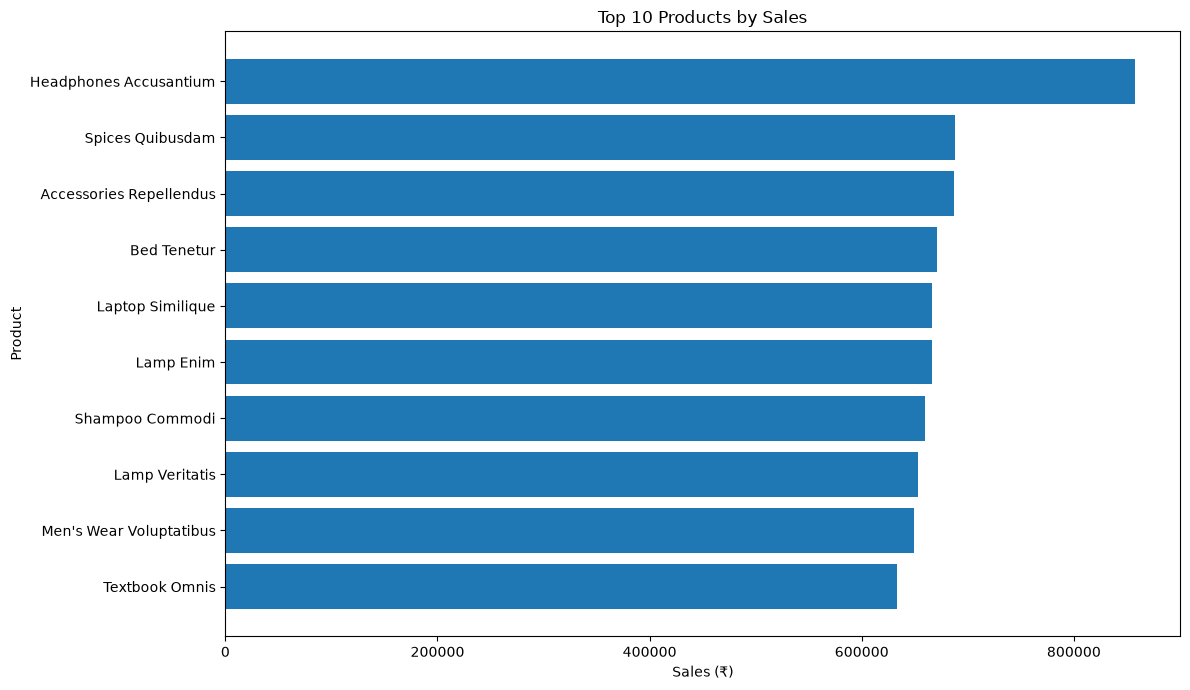

In [22]:
# Top 10 Products by Sales

plt.figure(figsize=(12, 7))

plt.barh(
    top_products_sales.index[::-1],
    top_products_sales.values[::-1]
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales (₹)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [23]:
# Top 10 Products by Profit

top_products_profit = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_profit)

Product Name
Headphones Accusantium     141873.79
Laptop Similique           136751.80
Accessories Repellendus    131526.41
Textbook Omnis             119166.66
Lipstick Accusamus         119017.65
Men's Wear Voluptatibus    118300.59
Shampoo Commodi            111950.64
Cushion Rem                111530.63
Wall Art Saepe             109548.98
Sugar Voluptates           108494.16
Name: Profit, dtype: float64


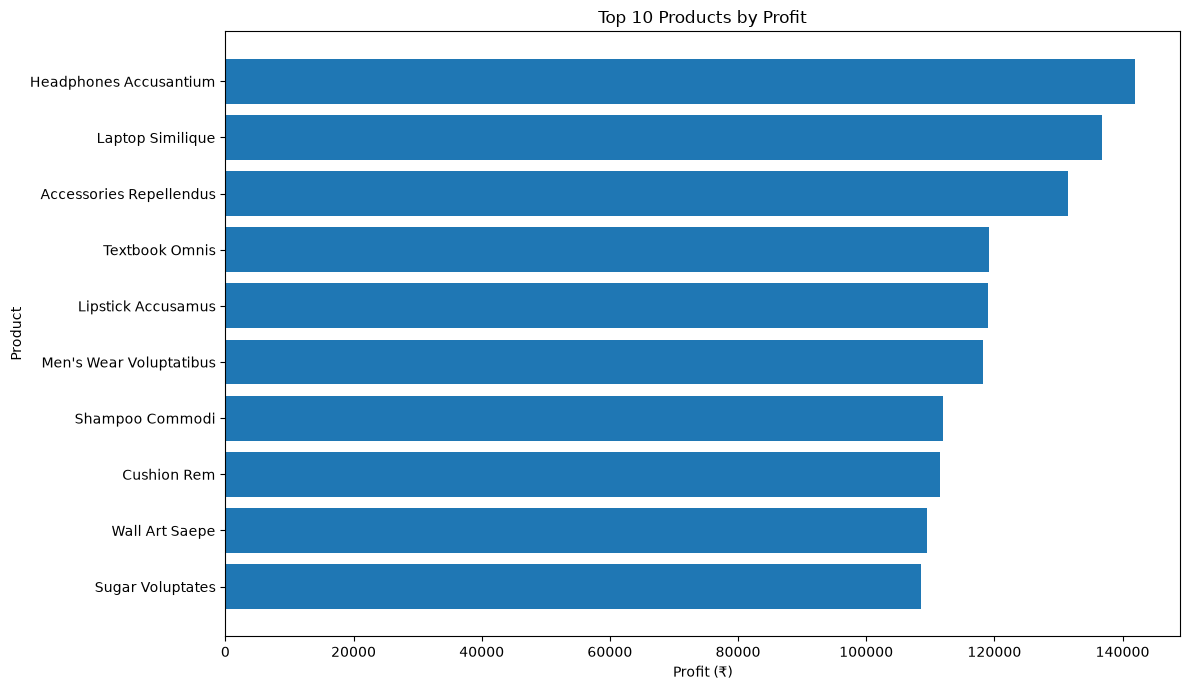

In [24]:
# Top 10 Products by Profit

plt.figure(figsize=(12, 7))

plt.barh(
    top_products_profit.index[::-1],
    top_products_profit.values[::-1]
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit (₹)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [25]:
# Regional Sales and Profit

region_performance = (
    df.groupby("Region")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

print(region_performance)

               Sales       Profit
Region                           
North   1.435782e+08  21343004.33
East    1.358116e+08  20532558.12
West    1.310460e+08  19580123.14
South   1.232302e+08  18253049.32


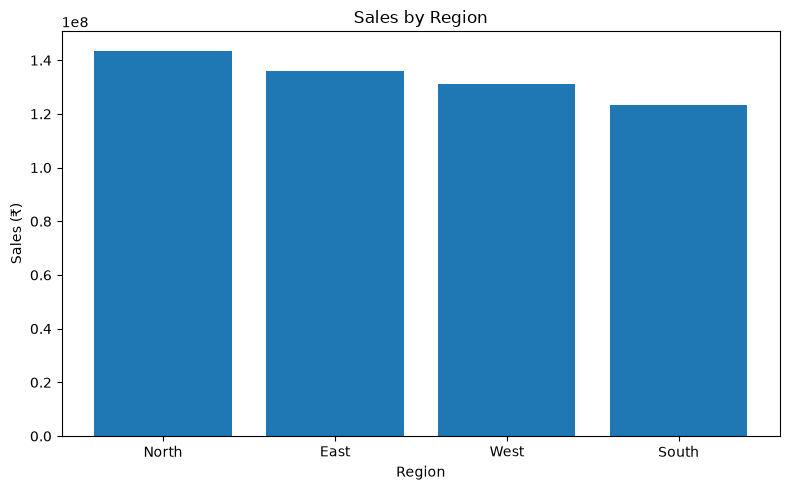

In [26]:
# Sales by Region

plt.figure(figsize=(8, 5))

plt.bar(
    region_performance.index,
    region_performance["Sales"]
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales (₹)")

plt.tight_layout()
plt.show()

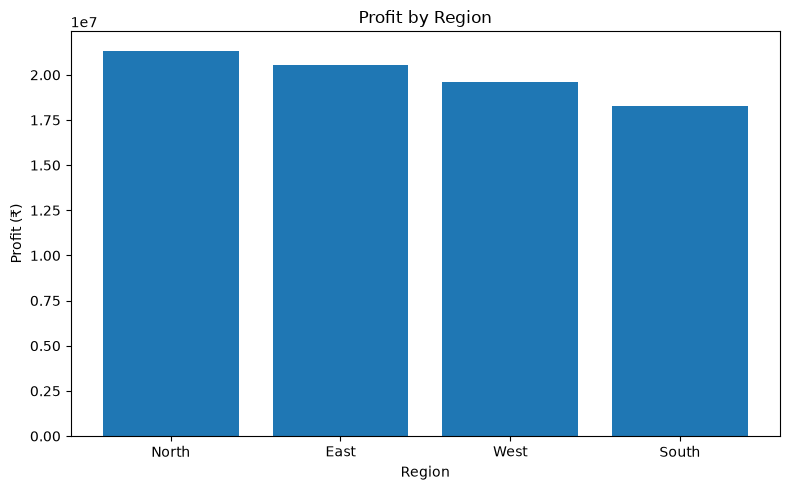

In [27]:
# Profit by Region

plt.figure(figsize=(8, 5))

plt.bar(
    region_performance.index,
    region_performance["Profit"]
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit (₹)")

plt.tight_layout()
plt.show()

In [28]:
# Top 10 Cities by Sales

top_cities_sales = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_cities_sales)

City
Bangalore      29989840.85
Lucknow        29901483.40
Guwahati       29606888.90
Chandigarh     29331057.35
Jaipur         29319402.90
Amritsar       28746184.20
Surat          28532934.65
Patna          27702815.20
Bhubaneswar    27088786.45
Ranchi         26948513.25
Name: Sales, dtype: float64


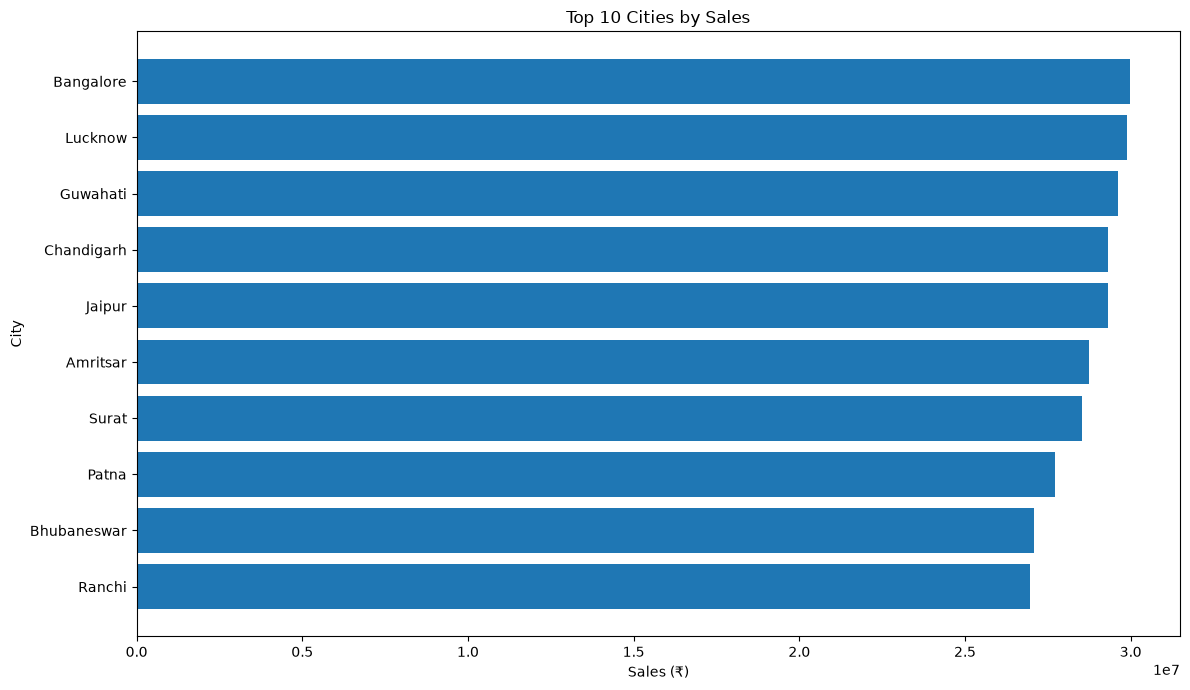

In [29]:
# Top 10 Cities by Sales

plt.figure(figsize=(12, 7))

plt.barh(
    top_cities_sales.index[::-1],
    top_cities_sales.values[::-1]
)

plt.title("Top 10 Cities by Sales")
plt.xlabel("Sales (₹)")
plt.ylabel("City")

plt.tight_layout()
plt.show()

In [30]:
# Top 10 Customers by Sales

top_customers_sales = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers_sales)

Customer Name
Aaryahi Madan         650151.9
Kimaya Vala           490935.0
Badal Rao             485698.0
Adira Dhingra         479389.0
Sumer Mann            469937.0
Nayantara Majumdar    459763.5
Prerak Shere          451862.4
Bhamini Sane          441410.6
Samarth Wagle         427715.5
Arhaan Basu           426563.6
Name: Sales, dtype: float64


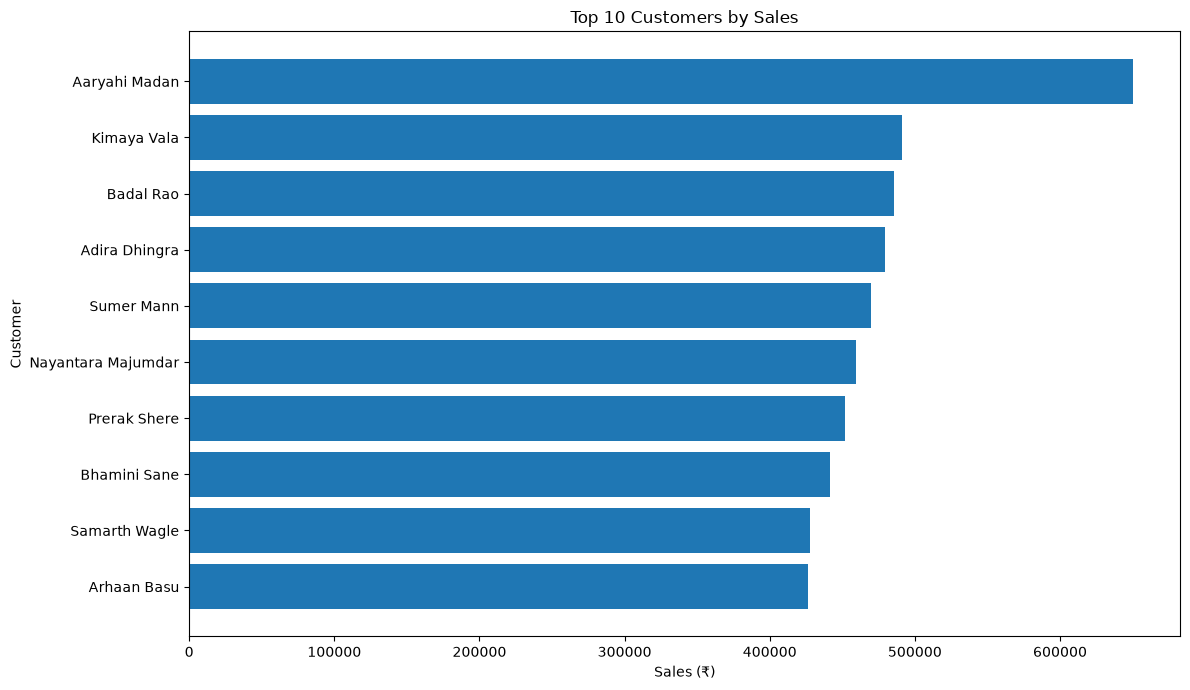

In [31]:
# Top 10 Customers by Sales

plt.figure(figsize=(12, 7))

plt.barh(
    top_customers_sales.index[::-1],
    top_customers_sales.values[::-1]
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales (₹)")
plt.ylabel("Customer")

plt.tight_layout()
plt.show()

In [32]:
# Customer and Order KPIs

unique_customers = df["Customer Name"].nunique()
total_orders = df["Order ID"].nunique()
average_order_value = df["Sales"].sum() / total_orders
average_profit_per_order = df["Profit"].sum() / total_orders

print("Unique Customers:", unique_customers)
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))
print("Average Profit per Order:", round(average_profit_per_order, 2))

Unique Customers: 4844
Total Orders: 5000
Average Order Value: 106733.2
Average Profit per Order: 15941.75


In [33]:
# Payment Method Analysis

payment_performance = (
    df.groupby("Payment Mode")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

payment_counts = df["Payment Mode"].value_counts()

print("Sales and Profit by Payment Mode:")
print(payment_performance)

print("\nNumber of Orders by Payment Mode:")
print(payment_counts)

Sales and Profit by Payment Mode:
                     Sales       Profit
Payment Mode                           
Net Banking   1.114655e+08  16964119.74
COD           1.088814e+08  16575845.53
Credit Card   1.060271e+08  15658639.35
Debit Card    1.053464e+08  15479323.07
UPI           1.019456e+08  15030807.22

Number of Orders by Payment Mode:
Payment Mode
Net Banking    1010
COD            1005
Debit Card     1003
Credit Card     994
UPI             988
Name: count, dtype: int64


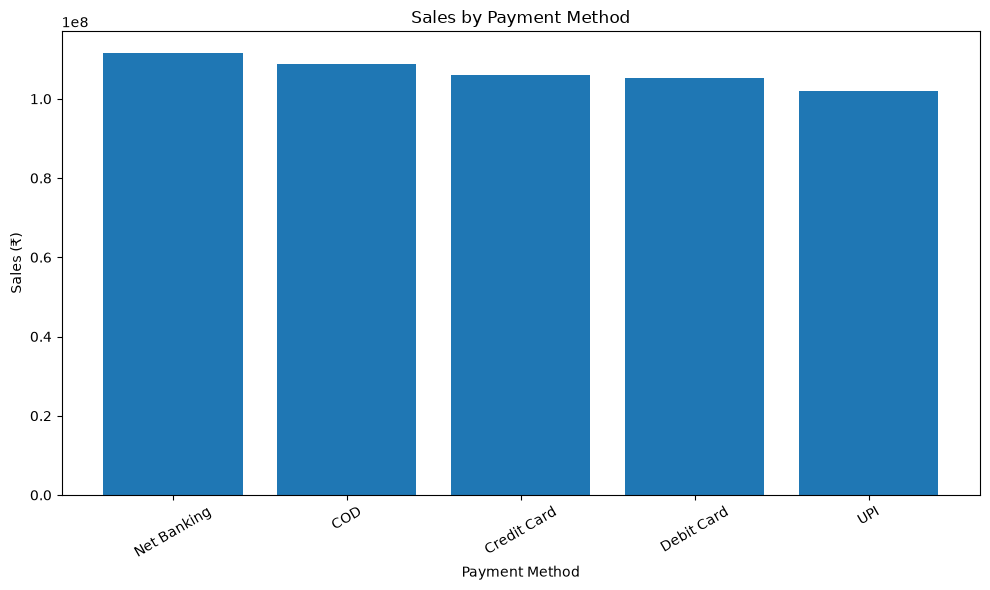

In [34]:
# Sales by Payment Method

plt.figure(figsize=(10, 6))

plt.bar(
    payment_performance.index,
    payment_performance["Sales"]
)

plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [35]:
# Discount Analysis

discount_performance = (
    df.groupby("Discount")[["Sales", "Profit"]]
    .agg(["sum", "mean"])
)

print(discount_performance)

                 Sales                      Profit              
                   sum           mean          sum          mean
Discount                                                        
0         1.171060e+08  117340.715431  17266608.70  17301.211122
5         1.120961e+08  114617.711759  17059182.93  17442.927331
10        1.105730e+08  108404.868529  16562542.62  16237.786882
15        9.728545e+07   98967.904730  14575951.61  14828.028087
20        9.660545e+07   94618.464251  14244449.05  13951.468217


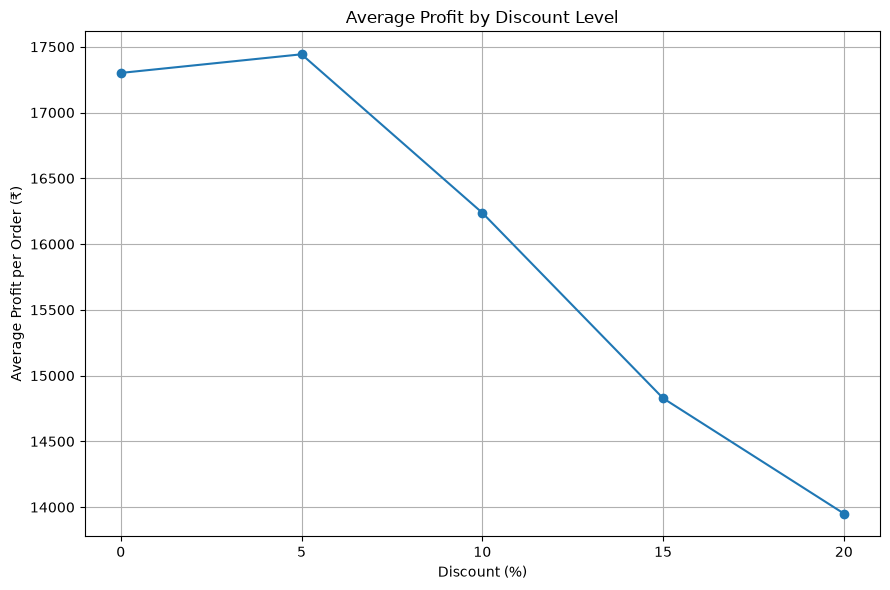

In [36]:
# Average Profit by Discount Level

avg_profit_discount = df.groupby("Discount")["Profit"].mean()

plt.figure(figsize=(9, 6))

plt.plot(
    avg_profit_discount.index,
    avg_profit_discount.values,
    marker="o"
)

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount (%)")
plt.ylabel("Average Profit per Order (₹)")
plt.xticks(avg_profit_discount.index)
plt.grid(True)

plt.tight_layout()
plt.show()

In [37]:
# Profit Margin by Product Category

category_margin = df.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

category_margin["Profit Margin (%)"] = (
    category_margin["Profit"] / category_margin["Sales"] * 100
)

category_margin = category_margin.sort_values(
    "Profit Margin (%)",
    ascending=False
)

print("Profit Margin by Product Category:")
print(category_margin)


Profit Margin by Product Category:
                   Sales      Profit  Profit Margin (%)
Category                                               
Furniture    56647187.90  8693087.03          15.346017
Clothing     55053908.30  8445750.29          15.340873
Electronics  52587883.95  8042133.88          15.292750
Toys         52227366.45  7986871.44          15.292503
Home Decor   57233222.35  8556846.94          14.950839
Sports       52069397.25  7739430.04          14.863683
Groceries    47883103.15  7075332.64          14.776262
Books        54932643.00  8076273.29          14.702139
Kitchen      54227902.30  7879573.29          14.530478
Beauty       50803409.70  7213436.07          14.198724


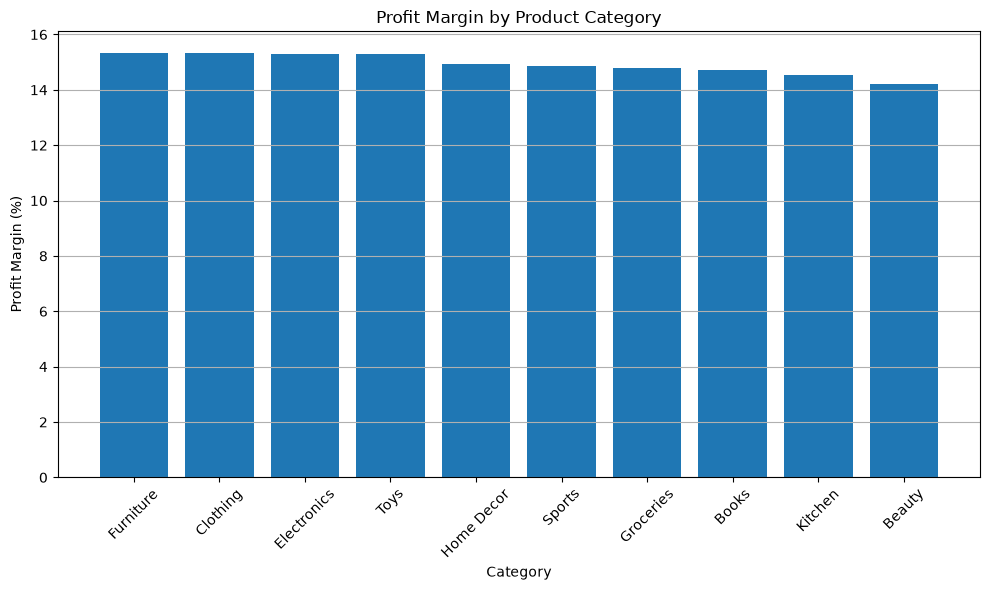

In [38]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_margin.index,
    category_margin["Profit Margin (%)"]
)

plt.title("Profit Margin by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [40]:
# Load cleaned data into SQLite database

from sqlalchemy import create_engine

# Make a copy so the original dataframe remains unchanged
sql_df = df.copy()

# Convert Year-Month Period column to text
if "Year-Month" in sql_df.columns:
    sql_df["Year-Month"] = sql_df["Year-Month"].astype(str)

# Database path
database_path = "../database/ecommerce_sales.db"

# Create SQLite connection
engine = create_engine(f"sqlite:///{database_path}")

# Load dataframe into SQL table
sql_df.to_sql(
    "sales",
    con=engine,
    if_exists="replace",
    index=False
)

print("Data loaded into SQLite successfully!")
print("Table name: sales")
print("Rows loaded:", len(sql_df))
print("Columns loaded:", len(sql_df.columns))

Data loaded into SQLite successfully!
Table name: sales
Rows loaded: 5000
Columns loaded: 15


In [41]:
# Verify SQL table

from sqlalchemy import text

with engine.connect() as connection:
    result = connection.execute(text("SELECT COUNT(*) FROM sales"))
    print("Total rows in SQL table:", result.scalar())

Total rows in SQL table: 5000


In [42]:
# First SQL business query
# Overall Sales Performance

query = """
SELECT
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Quantity) AS Total_Quantity
FROM sales;
"""

with engine.connect() as connection:
    result = connection.execute(text(query))
    row = result.fetchone()

print("Total Sales:", row[0])
print("Total Profit:", row[1])
print("Total Quantity Sold:", row[2])

Total Sales: 533666024.35
Total Profit: 79708734.91
Total Quantity Sold: 14963


In [43]:
# SQL Query: Sales and Profit by Category

query = """
SELECT
    Category,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Quantity) AS Total_Quantity
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC;
"""

with engine.connect() as connection:
    result = connection.execute(text(query))
    
    for row in result:
        print(row)

('Home Decor', 57233222.35, 8556846.94, 1539)
('Furniture', 56647187.9, 8693087.03, 1591)
('Clothing', 55053908.3, 8445750.29, 1513)
('Books', 54932643.0, 8076273.29, 1571)
('Kitchen', 54227902.3, 7879573.29, 1544)
('Electronics', 52587883.95, 8042133.88, 1426)
('Toys', 52227366.45, 7986871.44, 1475)
('Sports', 52069397.25, 7739430.04, 1489)
('Beauty', 50803409.7, 7213436.07, 1395)
('Groceries', 47883103.15, 7075332.64, 1420)


In [44]:
# SQL Query: Sales and Profit by Region

query = """
SELECT
    Region,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Quantity) AS Total_Quantity
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC;
"""

with engine.connect() as connection:
    result = connection.execute(text(query))

    print("Region Performance:")
    for row in result:
        print(row)

Region Performance:
('North', 143578246.1, 21343004.33, 3949)
('East', 135811637.95, 20532558.12, 3823)
('West', 131045973.35, 19580123.14, 3685)
('South', 123230166.95, 18253049.32, 3506)


In [45]:
# SQL Query: Top 10 Products by Sales

query = """
SELECT
    "Product Name",
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Quantity) AS Total_Quantity
FROM sales
GROUP BY "Product Name"
ORDER BY Total_Sales DESC
LIMIT 10;
"""

with engine.connect() as connection:
    result = connection.execute(text(query))

    print("Top 10 Products by Sales:")
    for row in result:
        print(row)

Top 10 Products by Sales:
('Headphones Accusantium', 857184.2, 141873.79, 14)
('Spices Quibusdam', 687651.25, 96587.33, 13)
('Accessories Repellendus', 687083.3, 131526.41, 11)
('Bed Tenetur', 670994.8, 100233.59, 11)
('Laptop Similique', 666640.6, 136751.8, 11)
('Lamp Enim', 665920.2, 93638.94, 16)
('Shampoo Commodi', 659546.6, 111950.64, 11)
('Lamp Veritatis', 652909.5, 62922.96, 12)
("Men's Wear Voluptatibus", 649048.0, 118300.59, 10)
('Textbook Omnis', 633246.25, 119166.66, 14)


In [46]:
# SQL Query: Top 10 Products by Profit

query = """
SELECT
    "Product Name",
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Quantity) AS Total_Quantity
FROM sales
GROUP BY "Product Name"
ORDER BY Total_Profit DESC
LIMIT 10;
"""

with engine.connect() as connection:
    result = connection.execute(text(query))

    print("Top 10 Products by Profit:")
    for row in result:
        print(row)

Top 10 Products by Profit:
('Headphones Accusantium', 857184.2, 141873.79, 14)
('Laptop Similique', 666640.6, 136751.8, 11)
('Accessories Repellendus', 687083.3, 131526.41, 11)
('Textbook Omnis', 633246.25, 119166.66, 14)
('Lipstick Accusamus', 610403.0, 119017.65, 9)
("Men's Wear Voluptatibus", 649048.0, 118300.59, 10)
('Shampoo Commodi', 659546.6, 111950.64, 11)
('Cushion Rem', 517582.8, 111530.63, 8)
('Wall Art Saepe', 509854.1, 109548.98000000001, 14)
('Sugar Voluptates', 547529.4, 108494.16, 9)


In [47]:
# SQL Query: Top 10 Customers by Sales

query = """
SELECT
    "Customer Name",
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    COUNT("Order ID") AS Total_Orders
FROM sales
GROUP BY "Customer Name"
ORDER BY Total_Sales DESC
LIMIT 10;
"""

with engine.connect() as connection:
    result = connection.execute(text(query))

    print("Top 10 Customers by Sales:")
    for row in result:
        print(row)

Top 10 Customers by Sales:
('Aaryahi Madan', 650151.9, 107156.36, 3)
('Kimaya Vala', 490935.0, 43004.16, 2)
('Badal Rao', 485698.0, 31990.42, 2)
('Adira Dhingra', 479389.0, 64959.22, 2)
('Sumer Mann', 469937.0, 99924.94, 2)
('Nayantara Majumdar', 459763.5, 58948.53, 2)
('Prerak Shere', 451862.4, 85631.81, 2)
('Bhamini Sane', 441410.6, 79309.81, 2)
('Samarth Wagle', 427715.5, 63410.58, 2)
('Arhaan Basu', 426563.6, 39473.009999999995, 2)


In [48]:
# SQL Query: Payment Method Performance

query = """
SELECT
    "Payment Mode",
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    COUNT("Order ID") AS Total_Orders
FROM sales
GROUP BY "Payment Mode"
ORDER BY Total_Sales DESC;
"""

with engine.connect() as connection:
    result = connection.execute(text(query))

    print("Payment Method Performance:")
    for row in result:
        print(row)

Payment Method Performance:
('Net Banking', 111465516.05, 16964119.74, 1010)
('COD', 108881396.25, 16575845.53, 1005)
('Credit Card', 106027144.9, 15658639.35, 994)
('Debit Card', 105346381.65, 15479323.07, 1003)
('UPI', 101945585.5, 15030807.22, 988)


In [49]:
# SQL Query: Discount vs Profit Analysis

query = """
SELECT
    Discount,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    AVG(Profit) AS Average_Profit
FROM sales
GROUP BY Discount
ORDER BY Discount;
"""

with engine.connect() as connection:
    result = connection.execute(text(query))

    print("Discount vs Profit Analysis:")
    for row in result:
        print(row)

Discount vs Profit Analysis:
(0, 117106034.0, 17266608.7, 17301.211122244487)
(5, 112096122.1, 17059182.93, 17442.92733128834)
(10, 110572965.9, 16562542.62, 16237.78688235294)
(15, 97285450.35, 14575951.61, 14828.028087487282)
(20, 96605452.0, 14244449.05, 13951.468217433889)


In [50]:
# SQL Query: Top 10 Customers by Sales

query = """
SELECT
    "Customer Name",
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    COUNT(*) AS Total_Orders
FROM sales
GROUP BY "Customer Name"
ORDER BY Total_Sales DESC
LIMIT 10;
"""

with engine.connect() as connection:
    result = connection.execute(text(query))

    print("Top 10 Customers by Sales:")
    for row in result:
        print(row)

Top 10 Customers by Sales:
('Aaryahi Madan', 650151.9, 107156.36, 3)
('Kimaya Vala', 490935.0, 43004.16, 2)
('Badal Rao', 485698.0, 31990.42, 2)
('Adira Dhingra', 479389.0, 64959.22, 2)
('Sumer Mann', 469937.0, 99924.94, 2)
('Nayantara Majumdar', 459763.5, 58948.53, 2)
('Prerak Shere', 451862.4, 85631.81, 2)
('Bhamini Sane', 441410.6, 79309.81, 2)
('Samarth Wagle', 427715.5, 63410.58, 2)
('Arhaan Basu', 426563.6, 39473.009999999995, 2)


In [51]:
# Advanced SQL: Most Profitable Product in Each Category

query = """
SELECT
    Category,
    "Product Name",
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Category, "Product Name"
ORDER BY Category, Total_Profit DESC;
"""

with engine.connect() as connection:
    result = connection.execute(text(query))

    print("Product Profitability by Category:")
    
    current_category = None
    
    for row in result:
        category = row[0]
        
        if category != current_category:
            print("\nCategory:", category)
            print("-" * 50)
            current_category = category
            
        print(row[1], "-> ₹", round(row[2], 2))

Product Profitability by Category:

Category: Beauty
--------------------------------------------------
Lipstick Accusamus -> ₹ 119017.65
Shampoo Commodi -> ₹ 111950.64
Foundation Perspiciatis -> ₹ 101007.85
Lipstick Laborum -> ₹ 98403.18
Lipstick Facilis -> ₹ 86486.3
Shampoo Reprehenderit -> ₹ 82744.41
Perfume Neque -> ₹ 80330.68
Face Cream Repellendus -> ₹ 77192.95
Perfume Voluptates -> ₹ 72829.75
Face Cream Dolorem -> ₹ 71866.56
Perfume Maxime -> ₹ 68224.67
Foundation Quisquam -> ₹ 68054.98
Shampoo Molestias -> ₹ 64508.18
Perfume Unde -> ₹ 60998.49
Face Cream In -> ₹ 60652.87
Face Cream Aliquid -> ₹ 57469.12
Face Cream Iure -> ₹ 57443.39
Lipstick Fuga -> ₹ 56820.68
Lipstick Eum -> ₹ 55240.36
Lipstick Numquam -> ₹ 53880.28
Face Cream Aliquam -> ₹ 52874.6
Foundation Cumque -> ₹ 52488.18
Perfume Nihil -> ₹ 50723.79
Perfume Mollitia -> ₹ 50630.69
Shampoo Fugit -> ₹ 49720.18
Face Cream Quod -> ₹ 48897.74
Shampoo Molestiae -> ₹ 48568.69
Lipstick Alias -> ₹ 46932.25
Face Cream Nihil -> ₹ 4

In [52]:
# Advanced SQL: Most Profitable Product in Each Category

query = """
SELECT Category, "Product Name", Total_Profit
FROM (
    SELECT
        Category,
        "Product Name",
        SUM(Profit) AS Total_Profit,
        ROW_NUMBER() OVER (
            PARTITION BY Category
            ORDER BY SUM(Profit) DESC
        ) AS rn
    FROM sales
    GROUP BY Category, "Product Name"
)
WHERE rn = 1
ORDER BY Total_Profit DESC;
"""

with engine.connect() as connection:
    result = connection.execute(text(query))

    print("Most Profitable Product in Each Category:")
    print("-" * 60)

    for row in result:
        print(f"{row[0]} → {row[1]} → ₹{row[2]:,.2f}")

Most Profitable Product in Each Category:
------------------------------------------------------------
Electronics → Headphones Accusantium → ₹141,873.79
Clothing → Accessories Repellendus → ₹131,526.41
Books → Textbook Omnis → ₹119,166.66
Beauty → Lipstick Accusamus → ₹119,017.65
Home Decor → Cushion Rem → ₹111,530.63
Groceries → Sugar Voluptates → ₹108,494.16
Furniture → Table Atque → ₹103,522.06
Toys → Puzzle Ut → ₹103,094.25
Kitchen → Microwave Reiciendis → ₹100,207.17
Sports → Tennis Racket Culpa → ₹90,008.53


In [53]:
# Customer Purchase Frequency

query = """
SELECT
    "Customer Name",
    COUNT(*) AS Total_Orders,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY "Customer Name"
ORDER BY Total_Orders DESC, Total_Sales DESC
LIMIT 10;
"""

with engine.connect() as connection:
    result = connection.execute(text(query))

    print("Top 10 Customers by Number of Orders:")
    print("-" * 65)

    for row in result:
        print(row)

Top 10 Customers by Number of Orders:
-----------------------------------------------------------------
('Aaryahi Madan', 3, 650151.9, 107156.36)
('Vritika Cherian', 3, 176867.09999999998, 18130.1)
('Kimaya Vala', 2, 490935.0, 43004.16)
('Badal Rao', 2, 485698.0, 31990.42)
('Adira Dhingra', 2, 479389.0, 64959.22)
('Sumer Mann', 2, 469937.0, 99924.94)
('Nayantara Majumdar', 2, 459763.5, 58948.53)
('Prerak Shere', 2, 451862.4, 85631.81)
('Bhamini Sane', 2, 441410.6, 79309.81)
('Samarth Wagle', 2, 427715.5, 63410.58)


In [54]:
# Repeat Customer Analysis

query = """
SELECT
    "Customer Name",
    COUNT(*) AS Total_Orders,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY "Customer Name"
HAVING COUNT(*) > 1
ORDER BY Total_Orders DESC, Total_Sales DESC;
"""

with engine.connect() as connection:
    result = connection.execute(text(query))

    print("Repeat Customers:")
    print("-" * 65)

    repeat_count = 0

    for row in result:
        print(row)
        repeat_count += 1

print("\nTotal Repeat Customers:", repeat_count)

Repeat Customers:
-----------------------------------------------------------------
('Aaryahi Madan', 3, 650151.9, 107156.36)
('Vritika Cherian', 3, 176867.09999999998, 18130.1)
('Kimaya Vala', 2, 490935.0, 43004.16)
('Badal Rao', 2, 485698.0, 31990.42)
('Adira Dhingra', 2, 479389.0, 64959.22)
('Sumer Mann', 2, 469937.0, 99924.94)
('Nayantara Majumdar', 2, 459763.5, 58948.53)
('Prerak Shere', 2, 451862.4, 85631.81)
('Bhamini Sane', 2, 441410.6, 79309.81)
('Samarth Wagle', 2, 427715.5, 63410.58)
('Arhaan Basu', 2, 426563.6, 39473.009999999995)
('Reyansh Bahri', 2, 422780.0, 36033.17)
('Arnav Karpe', 2, 404417.6, 41465.94)
('Jayant Khurana', 2, 403114.6, 48607.43)
('Jivika Magar', 2, 389687.15, 61268.44)
('Anya Goyal', 2, 382043.2, 72577.63)
('Fateh Madan', 2, 376668.0, 64447.299999999996)
('Trisha Lad', 2, 376296.2, 51840.06999999999)
('Riaan Bassi', 2, 370386.65, 35187.399999999994)
('Lakshay Arya', 2, 370085.4, 46043.56)
('Shlok Venkataraman', 2, 366957.3, 84815.42)
('Saanvi Sankar', 

In [55]:
# Repeat Customer Rate

query = """
SELECT
    COUNT(DISTINCT "Customer Name") AS Total_Customers,
    COUNT(DISTINCT CASE
        WHEN "Customer Name" IN (
            SELECT "Customer Name"
            FROM sales
            GROUP BY "Customer Name"
            HAVING COUNT(*) > 1
        )
        THEN "Customer Name"
    END) AS Repeat_Customers
FROM sales;
"""

with engine.connect() as connection:
    result = connection.execute(text(query))
    row = result.fetchone()

total_customers = row[0]
repeat_customers = row[1]

repeat_rate = (repeat_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Repeat Customers:", repeat_customers)
print("Repeat Customer Rate:", round(repeat_rate, 2), "%")

Total Customers: 4844
Repeat Customers: 154
Repeat Customer Rate: 3.18 %


In [56]:
# Customer Retention Analysis

query = """
SELECT
    CASE
        WHEN COUNT(*) > 1 THEN 'Repeat Customer'
        ELSE 'One-Time Customer'
    END AS Customer_Type,
    COUNT(*) AS Customer_Count
FROM sales
GROUP BY "Customer Name"
"""

with engine.connect() as connection:
    result = connection.execute(text(query))

    customer_types = {}

    for row in result:
        customer_type = row[0]
        customer_types[customer_type] = customer_types.get(customer_type, 0) + 1

print("Customer Retention Analysis:")
print("----------------------------")

for customer_type, count in customer_types.items():
    print(customer_type + ":", count)

Customer Retention Analysis:
----------------------------
One-Time Customer: 4690
Repeat Customer: 154


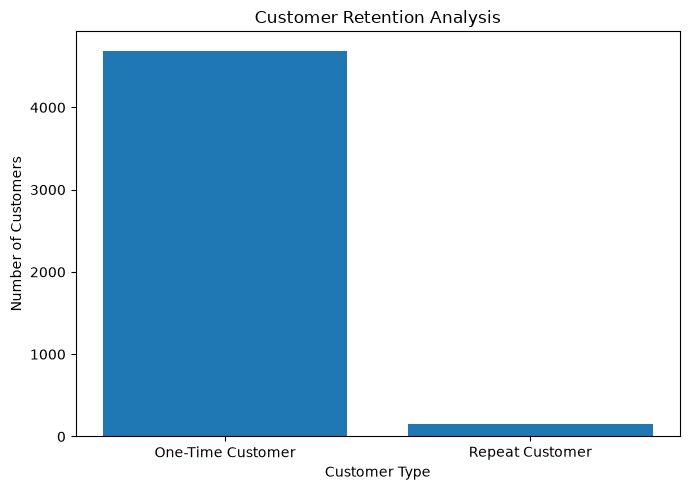

In [57]:
# Customer Retention Chart

labels = list(customer_types.keys())
values = list(customer_types.values())

plt.figure(figsize=(7, 5))

plt.bar(labels, values)

plt.title("Customer Retention Analysis")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [58]:
# Customer Retention Percentage

total = sum(customer_types.values())

for customer_type, count in customer_types.items():
    percentage = (count / total) * 100
    print(f"{customer_type}: {percentage:.2f}%")

One-Time Customer: 96.82%
Repeat Customer: 3.18%


# Key Business Insights

## 1. Overall Performance
- Total sales: ₹53.37 crore
- Total profit: ₹7.97 crore
- Total quantity sold: 14,963 units
- Average order value: ₹1,06,733

## 2. Customer Retention
- Total customers: 4,844
- One-time customers: 4,690 (96.82%)
- Repeat customers: 154 (3.18%)
- Customer retention is relatively low, indicating an opportunity to improve repeat purchases.

## 3. Category Performance
- Home Decor generated the highest sales.
- Furniture generated the highest profit.
- Beauty had the lowest profit margin among the categories.

## 4. Regional Performance
- North generated the highest sales and profit.
- South generated the lowest sales and profit among the four regions.

## 5. Discount Impact
- Profit is highest around the 5% discount level.
- Higher discounts are associated with lower average profit per order.
- A 20% discount produces substantially lower average profit than a 5% discount.

## 6. Product Performance
- Headphones Accusantium is the highest-selling and most profitable product.
- Several products contribute strongly to both sales and profit.

## 7. Business Recommendation
The business should focus on increasing repeat purchases, maintaining controlled discount levels, and strengthening high-performing categories, products, and regions.

In [59]:
# Test Query 13: Most Profitable Product in Each Category

from sqlalchemy import text

query = """
SELECT
    Category,
    "Sub-Category",
    Total_Profit
FROM (
    SELECT
        Category,
        "Sub-Category",
        SUM(Profit) AS Total_Profit,
        ROW_NUMBER() OVER (
            PARTITION BY Category
            ORDER BY SUM(Profit) DESC
        ) AS Rank
    FROM sales
    GROUP BY Category, "Sub-Category"
)
WHERE Rank = 1
ORDER BY Total_Profit DESC;
"""

with engine.connect() as connection:
    result = connection.execute(text(query))

    print("Most Profitable Product in Each Category:")
    print("-" * 60)

    for row in result:
        print(row)

Most Profitable Product in Each Category:
------------------------------------------------------------
('Furniture', 'Sofa', 2304898.78)
('Home Decor', 'Lamp', 2247216.13)
('Sports', 'Tennis Racket', 1946587.5)
('Books', 'Non-Fiction', 1945175.03)
('Electronics', 'Headphones', 1867457.8)
('Clothing', "Women's Wear", 1846403.61)
('Kitchen', 'Juicer', 1743368.29)
('Toys', 'RC Car', 1726107.31)
('Beauty', 'Face Cream', 1599375.99)
('Groceries', 'Rice', 1549703.98)


In [60]:
# Test Query 14: Customer Retention Summary

query = """
SELECT
    CASE
        WHEN Order_Count > 1 THEN 'Repeat Customer'
        ELSE 'One-Time Customer'
    END AS Customer_Type,
    COUNT(*) AS Customer_Count
FROM (
    SELECT
        "Customer Name",
        COUNT(*) AS Order_Count
    FROM sales
    GROUP BY "Customer Name"
) AS customer_orders
GROUP BY Customer_Type;
"""

with engine.connect() as connection:
    result = connection.execute(text(query))

    print("Customer Retention Summary:")
    print("-" * 40)

    for row in result:
        print(row)

Customer Retention Summary:
----------------------------------------
('One-Time Customer', 4690)
('Repeat Customer', 154)
